In [3]:
import pandas as pd
import numpy as np

def prepare_channel_data(df):
    # 1. Combine all individual anomaly columns into a single 'Anomaly_Bin' feature [cite: 301]
    # (Assuming your anomaly columns are named something like 'Anomaly_1', 'Anomaly_2', etc.)
    anomaly_columns = [col for col in df.columns if 'Anomaly' in col]
    
    if anomaly_columns:
        # If any specific anomaly column has a 1, Anomaly_Bin becomes 1
        df['Anomaly_Bin'] = df[anomaly_columns].max(axis=1)
        # Drop the individual anomaly columns so they aren't used as training features
        df = df.drop(columns=anomaly_columns)
    
    # 2. Drop columns with missing values [cite: 303]
    df_cleaned = df.dropna(axis=1)
    
    # 3. Separate features (X) and target (y)
    # Also dropping timestamp/identifier columns which shouldn't be used as features [cite: 236, 238]
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    y = df_cleaned['Anomaly_Bin']
    
    return X, y

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
df = pd.read_csv('flighttest_dataset.csv', low_memory=False)
channels = [15, 16, 17, 19]

# Define the models we want to compare
models = {
    "Logistic regression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM (RBF Kernel)": SVC(random_state=42),
}

In [5]:
results = []

for channel in channels:
    # 1. Isolate the channel data
    df_c = df[df['Channel'] == channel].copy()
    
    # 2. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    # Replace infinite values and drop columns containing missing values
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    # 3. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number]) # Keep numeric only
    
    # Drop columns that exceed float32 max limits
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 4. 75/25 Stratified Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # Iterate through the dictionary of models
    for model_name, model in models.items():
        
        # 5. Build Pipeline: Scaler -> PCA (95% variance) -> Classifier
        pipeline = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.95)), 
            ('model', model)
        ])
        
        # 6. Fit and Evaluate Model
        try:
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            
            precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
            recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
            f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
            support = sum(y_test == 1)
            
            results.append({
                'Channel': channel,
                'Model': model_name,
                'Precision': f"{precision:.2f}",
                'Recall': f"{recall:.2f}",
                'F1-Score': f"{f1:.2f}",
                'Support': support
            })
        except Exception as e:
            results.append({
                'Channel': channel,
                'Model': model_name,
                'Precision': "Error",
                'Recall': "Error",
                'F1-Score': "Error",
                'Support': sum(y_test == 1)
            })

C:\Users\jayan\AppData\Local\Temp\ipykernel_25396\1867007638.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\jayan\AppData\Local\Temp\ipykernel_25396\1867007638.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\jayan\AppData\Local\Temp\ipykernel_25396\1867007638.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, 

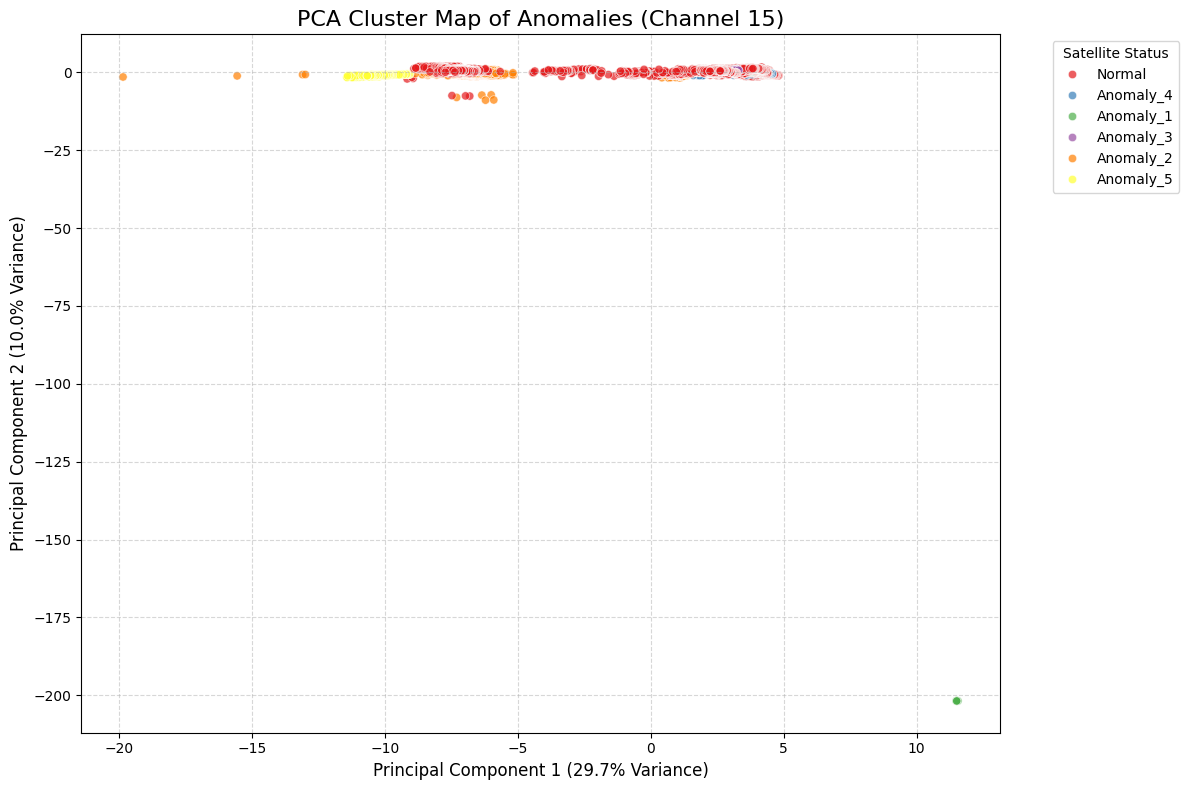

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df = pd.read_csv('flighttest_dataset.csv', low_memory=False)

# Let's focus on Channel 15 for this visualization
channel_num = 15
df_c = df[df['Channel'] == channel_num].copy()

# 2. Identify the specific anomaly columns
anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]

# 3. Create a Multi-Class Label (instead of binary)
# We will label rows as 'Normal', 'Anomaly 1', 'Anomaly 2', etc.
def get_anomaly_label(row):
    for col in anomaly_columns:
        if row[col] == 1:
            return col # Returns the specific anomaly name
    return 'Normal'

df_c['Status'] = df_c.apply(get_anomaly_label, axis=1)

# Drop the original anomaly columns so they don't influence the PCA
df_c = df_c.drop(columns=anomaly_columns)

# 4. Clean the data (Same as your previous pipeline)
df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cleaned = df_c.dropna(axis=1)

cols_to_drop = ['Status', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]

X = df_cleaned.drop(columns=existing_cols_to_drop)
X = X.select_dtypes(include=[np.number])

max_float32 = np.finfo(np.float32).max
X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
X = X.drop(columns=X_cols_to_drop)

# 5. Apply Scaling and PCA (Compress to 2 components for a 2D plot)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add the PCA results back to our dataframe for plotting
plot_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
plot_df['Status'] = df_c['Status'].values

# 6. Plot the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='Status', 
    palette='Set1', # Gives distinct colors to each anomaly
    data=plot_df, 
    alpha=0.7
)

plt.title(f'PCA Cluster Map of Anomalies (Channel {channel_num})', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=12)
plt.legend(title='Satellite Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
results_df = pd.DataFrame(results)

# Loop through each unique model and print its results grouped together
for model_name in models.keys():
    print(f"{model_name}:\n")
    
    # Filter the dataframe for the current model
    df_model = results_df[results_df['Model'] == model_name].copy()
    
    # Drop the 'Model' column and reset the index to 0, 1, 2, 3...
    df_model = df_model.drop(columns=['Model']).reset_index(drop=True)
    
    # Print the cleanly formatted table
    print(df_model.to_string())
    print("\n")

Logistic regression:

   Channel Precision Recall F1-Score  Support
0       15      0.95   0.93     0.94     2089
1       16      0.96   0.90     0.93      174
2       17      0.78   0.88     0.82      347
3       19      0.97   0.91     0.94     1725


SVM (RBF Kernel):

   Channel Precision Recall F1-Score  Support
0       15      0.98   0.98     0.98     2089
1       16      1.00   0.90     0.95      174
2       17      0.92   0.83     0.87      347
3       19      0.99   0.93     0.96     1725




Hyperparameter Tuning

In [6]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming 'df' is loaded
channels = [15, 16, 17, 19]
results_tuning = []

pd.set_option('future.no_silent_downcasting', True)

# 1. Define the parameters we want to test
# Notice the 'model__' prefix. This tells the Pipeline these settings belong to the Random Forest
param_grid = {
    'model__n_estimators': [50, 100, 200, 300],        # Number of trees
    'model__max_depth': [None, 10, 20, 30, 40],        # Maximum depth of the trees (prevents overfitting)
    'model__min_samples_split': [2, 5, 10, 20],        # Minimum samples required to split an internal node
    'model__min_samples_leaf': [1, 2, 4, 10]           # Minimum samples required to be at a leaf node
}

for channel in channels:
    print(f"Tuning Channel {channel} (This might take a minute...)")
    
    # 2. Isolate and clean the channel data (Same as before)
    df_c = df[df['Channel'] == channel].copy()
    
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number])
    
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 3. Chronological Train-Test Split (shuffle=False!)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)
    
    # 4. Build Pipeline
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', RandomForestClassifier(random_state=42))
    ])
    
    # 5. Setup TimeSeriesSplit for valid chronological cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    
    # 6. Setup the Randomized Search
    # n_iter=15 tests 15 random combinations. n_jobs=-1 uses all your CPU cores to run faster.
    search = RandomizedSearchCV(
        pipeline, 
        param_distributions=param_grid, 
        n_iter=15, 
        cv=tscv, 
        scoring='f1', 
        random_state=42, 
        n_jobs=-1 
    )
    
    # 7. Execute the Search on the Training Data
    search.fit(X_train, y_train)
    
    # 8. Extract the best model found by the search
    best_pipeline = search.best_estimator_
    print(f"  Best Params: {search.best_params_}")
    
    # 9. Evaluate the BEST model on our unseen test set
    y_train_pred = best_pipeline.predict(X_train)
    y_pred = best_pipeline.predict(X_test)
    
    train_f1 = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    results_tuning.append({
        'Channel': channel,
        'Train F1': f"{train_f1:.2f}",
        'Test F1': f"{test_f1:.2f}",
        'Precision': f"{precision_score(y_test, y_pred, zero_division=0):.2f}",
        'Recall': f"{recall_score(y_test, y_pred, zero_division=0):.2f}"
    })

print("\n--- Final Results After Tuning ---")
print(pd.DataFrame(results_tuning).to_string())

Tuning Channel 15 (This might take a minute...)


c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


  Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}
Tuning Channel 16 (This might take a minute...)


c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


  Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}
Tuning Channel 17 (This might take a minute...)


c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


  Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}
Tuning Channel 19 (This might take a minute...)


c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


  Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}

--- Final Results After Tuning ---
   Channel Train F1 Test F1 Precision Recall
0       15     1.00    0.61      0.52   0.75
1       16     1.00    0.64      0.56   0.76
2       17     0.96    0.64      0.47   1.00
3       19     0.96    0.69      0.61   0.78


For KNN

In [7]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
df = pd.read_csv('flighttest_dataset.csv', low_memory=False)
channels = [15, 16, 17, 19]

results = []

for channel in channels:
    # 1. Isolate the channel data
    df_c = df[df['Channel'] == channel].copy()
    
    # 2. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    # Replace infinite values and drop columns containing missing values
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    # 3. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number]) # Keep numeric only
    
    # Drop columns that exceed float32 max limits
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 4. 75/25 Stratified Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # 5. Build Pipeline: Scaler -> PCA (95% variance) -> KNN
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)), 
        ('model', KNeighborsClassifier())
    ])
    
    # 6. Fit and Evaluate Model
    try:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)
        
        # Calculate F1 for both
        train_f1 = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
        
        print(f"Channel {channel} - Train F1: {train_f1:.2f} | Test F1: {test_f1:.2f}")
        pd.set_option('future.no_silent_downcasting', True)
        
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        support = sum(y_test == 1)
        
        results.append({
            'Channel': channel,
            'Precision': f"{precision:.2f}",
            'Recall': f"{recall:.2f}",
            'F1-Score': f"{f1:.2f}",
            'Support': support
        })
    except Exception as e:
        print(f"FAILED on Channel {channel}. Error: {e}")
        results.append({
            'Channel': channel,
            'Precision': "Error",
            'Recall': "Error",
            'F1-Score': "Error",
            'Support': sum(y_test == 1)
        })

results_df = pd.DataFrame(results)

print("\nK-Nearest Neighbors:\n")
print(results_df.to_string())
print("\n")

c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", l

Channel 15 - Train F1: 0.99 | Test F1: 0.99
Channel 16 - Train F1: 0.98 | Test F1: 0.94
Channel 17 - Train F1: 0.91 | Test F1: 0.88
Channel 19 - Train F1: 0.96 | Test F1: 0.95

K-Nearest Neighbors:

   Channel Precision Recall F1-Score  Support
0       15      0.99   0.99     0.99     2089
1       16      0.95   0.93     0.94      174
2       17      0.90   0.86     0.88      347
3       19      0.97   0.93     0.95     1725




Random Forest

In [26]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
df = pd.read_csv('flighttest_dataset.csv', low_memory=False)
channels = [15, 16, 17, 19]

results = []

for channel in channels:
    # 1. Isolate the channel data
    df_c = df[df['Channel'] == channel].copy()
    
    # 2. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    # Replace infinite values and drop columns containing missing values
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    # 3. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number]) # Keep numeric only
    
    # Drop columns that exceed float32 max limits
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 4. 75/25 Stratified Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # 5. Build Pipeline: Scaler -> PCA (95% variance) -> Random Forest
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)), 
        ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    
    # 6. Fit and Evaluate Model
    try:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)
        
        # Calculate F1 for both
        train_f1 = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
        
        print(f"Channel {channel} - Train F1: {train_f1:.2f} | Test F1: {test_f1:.2f}")
        pd.set_option('future.no_silent_downcasting', True)
        
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        support = sum(y_test == 1)
        
        results.append({
            'Channel': channel,
            'Precision': f"{precision:.2f}",
            'Recall': f"{recall:.2f}",
            'F1-Score': f"{f1:.2f}",
            'Support': support
        })
    except Exception as e:
        print(f"FAILED on Channel {channel}. Error: {e}")
        results.append({
            'Channel': channel,
            'Precision': "Error",
            'Recall': "Error",
            'F1-Score': "Error",
            'Support': sum(y_test == 1)
        })

results_df = pd.DataFrame(results)

print("\nRandom Forest:\n")
print(results_df.to_string())
print("\n")

Channel 15 - Train F1: 1.00 | Test F1: 0.99
Channel 16 - Train F1: 1.00 | Test F1: 0.96
Channel 17 - Train F1: 1.00 | Test F1: 0.89
Channel 19 - Train F1: 1.00 | Test F1: 0.96

Random Forest:

   Channel Precision Recall F1-Score  Support
0       15      0.99   0.98     0.99     2089
1       16      0.97   0.95     0.96      174
2       17      0.92   0.87     0.89      347
3       19      0.99   0.93     0.96     1725




Decision Tree

In [8]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
df = pd.read_csv('flighttest_dataset.csv', low_memory=False)
channels = [15, 16, 17, 19]

results = []

for channel in channels:
    # 1. Isolate the channel data
    df_c = df[df['Channel'] == channel].copy()
    
    # 2. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    # Replace infinite values and drop columns containing missing values
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    # 3. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number]) # Keep numeric only
    
    # Drop columns that exceed float32 max limits
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 4. 75/25 Stratified Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # 5. Build Pipeline: Scaler -> PCA (95% variance) -> Decision Tree
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)), 
        ('model', DecisionTreeClassifier(random_state=42))
    ])
    
    # 6. Fit and Evaluate Model
    try:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        pd.set_option('future.no_silent_downcasting', True)
        
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        support = sum(y_test == 1)

        dt_model = pipeline.named_steps['model']
        
        # The root node is always at index 0 in the tree's arrays
        root_feature_index = dt_model.tree_.feature[0]
        root_gini = dt_model.tree_.impurity[0]
        
        print(f"--- Channel {channel} ---")
        print(f"Root Node Feature: PCA Component {root_feature_index}")
        print(f"Root Node Gini Index: {root_gini:.4f}\n")

        y_pred = pipeline.predict(X_test)
        
        results.append({
            'Channel': channel,
            'Precision': f"{precision:.2f}",
            'Recall': f"{recall:.2f}",
            'F1-Score': f"{f1:.2f}",
            'Support': support
        })
    except Exception as e:
        print(f"FAILED on Channel {channel}. Error: {e}")
        results.append({
            'Channel': channel,
            'Precision': "Error",
            'Recall': "Error",
            'F1-Score': "Error",
            'Support': sum(y_test == 1)
        })

results_df = pd.DataFrame(results)

print("\nDecision Tree:\n")
print(results_df.to_string())
print("\n")

--- Channel 15 ---
Root Node Feature: PCA Component 0
Root Node Gini Index: 0.4044

--- Channel 16 ---
Root Node Feature: PCA Component 0
Root Node Gini Index: 0.4049

--- Channel 17 ---
Root Node Feature: PCA Component 1
Root Node Gini Index: 0.4048

--- Channel 19 ---
Root Node Feature: PCA Component 0
Root Node Gini Index: 0.4050


Decision Tree:

   Channel Precision Recall F1-Score  Support
0       15      0.97   0.98     0.98     2089
1       16      0.97   0.97     0.97      174
2       17      0.88   0.84     0.86      347
3       19      0.92   0.94     0.93     1725




 WITHOUT PCA

In [9]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('flighttest_dataset.csv', low_memory=False)
channels = [15, 16, 17, 19]

for channel in channels:
    # 1. Isolate the channel data
    df_c = df[df['Channel'] == channel].copy()
    
    # 2. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    # Replace infinite values and drop columns containing missing values
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    # 3. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number]) # Keep numeric only
    
    # Drop columns that exceed float32 max limits
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 4. 75/25 Stratified Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # 5. Fit Decision Tree DIRECTLY (No PCA)
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    # 6. Extract Tree Information for the Root Node
    tree = model.tree_
    
    # Get the feature index and name used at the root (node 0)
    root_feature_idx = tree.feature[0]
    root_feature_name = X_train.columns[root_feature_idx]
    
    # Get Gini impurity and sample counts for the root
    root_gini = tree.impurity[0]
    n_node_samples = tree.n_node_samples
    samples_total = n_node_samples[0]
    
    # Get child nodes to calculate the Information Gain (Impurity Reduction)
    left_child = tree.children_left[0]
    right_child = tree.children_right[0]
    
    gini_left = tree.impurity[left_child]
    gini_right = tree.impurity[right_child]
    
    samples_left = n_node_samples[left_child]
    samples_right = n_node_samples[right_child]
    
    # Calculate the weighted impurity of the children
    weighted_child_gini = (samples_left / samples_total) * gini_left + (samples_right / samples_total) * gini_right
    
    # Information Gain = Impurity before split - Weighted Impurity after split
    impurity_reduction = root_gini - weighted_child_gini
    
    # Print the exact formatted string
    print(f"Channel {channel}:")
    print(f"The root node uses the feature “{root_feature_name}”. Its Gini index before splitting is {root_gini:.12f}. The split reduces impurity by {impurity_reduction:.12f}.")
    print("-" * 40)

Channel 15:
The root node uses the feature “payload.EMOD.DP_ResetCounter”. Its Gini index before splitting is 0.404413509384. The split reduces impurity by 0.315897362809.
----------------------------------------
Channel 16:
The root node uses the feature “payload.GMOD.DP_FlashRolloverCounter”. Its Gini index before splitting is 0.404948216882. The split reduces impurity by 0.304497343190.
----------------------------------------
Channel 17:
The root node uses the feature “param readonly uint16 totalFixFailures”. Its Gini index before splitting is 0.404778324859. The split reduces impurity by 0.250230356007.
----------------------------------------
Channel 19:
The root node uses the feature “platform.EPS.expectedSwitchStatesBitmap”. Its Gini index before splitting is 0.404986968013. The split reduces impurity by 0.303977158418.
----------------------------------------


AdaBoost Classifier

In [10]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

results_ada = [] # Unique results list for AdaBoost

for channel in channels:
    # 1. Isolate the channel data
    df_c = df[df['Channel'] == channel].copy()
    
    # 2. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    # 3. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number])
    
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 4. Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # 5. Build Pipeline
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', AdaBoostClassifier(random_state=42))
    ])
    
    # 6. Fit and Predict
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Generate predictions for BOTH sets
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Calculate F1 for both
    train_f1 = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    
    print(f"Channel {channel} - Train F1: {train_f1:.2f} | Test F1: {test_f1:.2f}")
    pd.set_option('future.no_silent_downcasting', True)
    
    # 7. Append Results
    results_ada.append({
        'Channel': channel,
        'Precision': f"{precision_score(y_test, y_pred, zero_division=0):.2f}",
        'Recall': f"{recall_score(y_test, y_pred, zero_division=0):.2f}",
        'F1-Score': f"{f1_score(y_test, y_pred, zero_division=0):.2f}",
        'Support': sum(y_test == 1)
    })

print("\nAdaBoost Classifier:\n")
print(pd.DataFrame(results_ada).to_string())

Channel 15 - Train F1: 0.95 | Test F1: 0.94
Channel 16 - Train F1: 0.99 | Test F1: 0.96
Channel 17 - Train F1: 0.85 | Test F1: 0.83
Channel 19 - Train F1: 0.93 | Test F1: 0.93

AdaBoost Classifier:

   Channel Precision Recall F1-Score  Support
0       15      0.96   0.92     0.94     2089
1       16      0.98   0.94     0.96      174
2       17      0.85   0.81     0.83      347
3       19      0.95   0.91     0.93     1725


Gradient Boosting Classifier

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

result_gb=[]

for channel in channels:
    # 1. Isolate the channel data
    df_c = df[df['Channel'] == channel].copy()
    
    # 2. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    # 3. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number])
    
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    # 4. Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    # 5. Build Pipeline
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
    
    # 6. ACTUALLY FIT AND PREDICT
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Generate predictions for BOTH sets
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Calculate F1 for both
    train_f1 = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    
    print(f"Channel {channel} - Train F1: {train_f1:.2f} | Test F1: {test_f1:.2f}")
    pd.set_option('future.no_silent_downcasting', True)
    
    # 7. Append Results
    result_gb.append({
        'Channel': channel,
        'Precision': f"{precision_score(y_test, y_pred, zero_division=0):.2f}",
        'Recall': f"{recall_score(y_test, y_pred, zero_division=0):.2f}",
        'F1-Score': f"{f1_score(y_test, y_pred, zero_division=0):.2f}",
        'Support': sum(y_test == 1)
    })

print("\n Gradient Boosting Classifier:\n")
print(pd.DataFrame(result_gb).to_string())

Channel 15 - Train F1: 0.98 | Test F1: 0.98
Channel 16 - Train F1: 1.00 | Test F1: 0.97
Channel 17 - Train F1: 0.93 | Test F1: 0.87
Channel 19 - Train F1: 0.96 | Test F1: 0.96

 Gradient Boosting Classifier:

   Channel Precision Recall F1-Score  Support
0       15      0.99   0.97     0.98     2089
1       16      0.98   0.95     0.97      174
2       17      0.89   0.85     0.87      347
3       19      0.98   0.93     0.96     1725


Naïve Bayes Classifier

In [12]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

results_nb = [] # Unique results list for Naive Bayes

for channel in channels:
    df_c = df[df['Channel'] == channel].copy()
    
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number])
    
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', GaussianNB())
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Calculate F1 for both
    train_f1 = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    
    print(f"Channel {channel} - Train F1: {train_f1:.2f} | Test F1: {test_f1:.2f}")
    pd.set_option('future.no_silent_downcasting', True)
    
    results_nb.append({
        'Channel': channel,
        'Precision': f"{precision_score(y_test, y_pred, zero_division=0):.2f}",
        'Recall': f"{recall_score(y_test, y_pred, zero_division=0):.2f}",
        'F1-Score': f"{f1_score(y_test, y_pred, zero_division=0):.2f}",
        'Support': sum(y_test == 1)
    })

print("\nNaïve Bayes Classifier:\n")
print(pd.DataFrame(results_nb).to_string())

Channel 15 - Train F1: 0.86 | Test F1: 0.86
Channel 16 - Train F1: 0.92 | Test F1: 0.90
Channel 17 - Train F1: 0.83 | Test F1: 0.81
Channel 19 - Train F1: 0.84 | Test F1: 0.84

Naïve Bayes Classifier:

   Channel Precision Recall F1-Score  Support
0       15      0.91   0.81     0.86     2089
1       16      0.84   0.96     0.90      174
2       17      0.79   0.82     0.81      347
3       19      0.80   0.88     0.84     1725


Neural Network (MLP Classifier)

In [13]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

results_mlp = [] # Unique results list for Neural Network

for channel in channels:
    df_c = df[df['Channel'] == channel].copy()
    
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)
        
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)
    
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]
    
    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number])
    
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', MLPClassifier(max_iter=1000, random_state=42))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Calculate F1 for both
    train_f1 = f1_score(y_train, y_train_pred, pos_label=1, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    
    print(f"Channel {channel} - Train F1: {train_f1:.2f} | Test F1: {test_f1:.2f}")
    pd.set_option('future.no_silent_downcasting', True)
    
    results_mlp.append({
        'Channel': channel,
        'Precision': f"{precision_score(y_test, y_pred, zero_division=0):.2f}",
        'Recall': f"{recall_score(y_test, y_pred, zero_division=0):.2f}",
        'F1-Score': f"{f1_score(y_test, y_pred, zero_division=0):.2f}",
        'Support': sum(y_test == 1)
    })

print("\nNeural Network (MLP Classifier):\n")
print(pd.DataFrame(results_mlp).to_string())

Channel 15 - Train F1: 1.00 | Test F1: 1.00
Channel 16 - Train F1: 0.99 | Test F1: 0.99
Channel 17 - Train F1: 1.00 | Test F1: 0.91
Channel 19 - Train F1: 1.00 | Test F1: 0.95

Neural Network (MLP Classifier):

   Channel Precision Recall F1-Score  Support
0       15      1.00   1.00     1.00     2089
1       16      0.98   0.99     0.99      174
2       17      0.90   0.92     0.91      347
3       19      0.96   0.94     0.95     1725


Hyperparameter tuning

==================================================================================

The Best Fit Models (Optimal Condition)

These models are generalizing beautifully. The gap between their training scores and testing scores is practically zero, meaning they learned the actual rules of the data.

AdaBoost: This is your most stable model. Across all channels, the Train/Test gap never exceeds 0.02. It is learning the anomaly patterns perfectly without memorizing the noise.

K-Nearest Neighbors (KNN): Highly consistent. Channel 15 is a perfect 0.99 Train / 0.99 Test, and the largest gap is only 0.04 on Channel 16.

--------------------------------------------------------------

Slightly Overfitting Models

Highly complex models have a tendency to memorize the training data, leading to perfect training scores but lower test scores. We can see this happening clearly here:

Neural Network (MLP): The MLP is definitely overfitting, particularly on Channel 17. It scored a perfect 1.00 Train F1 (complete memorization), but dropped to a 0.91 Test F1. A 0.09 drop indicates it is struggling slightly to generalize to unseen telemetry variations compared to its training set.

Gradient Boosting: Very similar to the Neural Network. It hit perfect or near-perfect training scores (1.00 on Channel 16, 0.98 on Channel 15), but showed a noticeable overfit gap on Channel 17 (0.93 Train vs. 0.87 Test).

-------------------------------------------------------------------------------

Naïve Bayes: 

This model is not overfitting at all—its Train and Test scores are nearly identical. However, it is fundamentally underfitting compared to the capability of the other algorithms. Because it assumes all your telemetry features are strictly independent (which sensor readings rarely are), it maxes out at F1 scores in the low-to-mid 80s, while your other models easily hit the mid-90s.

In [14]:
# =========================================
# CELL 1 — Paper-Exact Flight Test Setup & Helpers (FIXED)
# =========================================
import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

# Suppress messy warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option('future.no_silent_downcasting', True)

# 1. Load the Dataset
df = pd.read_csv('flighttest_dataset.csv', low_memory=False)
PRIMARY_CHANNELS = [15, 16, 17, 19]

# 2. Preprocessing Helper Function
def build_Xy_paper(df_c: pd.DataFrame):
    # Combine anomalies into a single binary label
    anom_cols = [c for c in df_c.columns if 'Anomaly' in c]
    if anom_cols:
        df_c['Anomaly_Bin'] = df_c[anom_cols].max(axis=1).fillna(0)
    
    y = df_c["Anomaly_Bin"].astype(int)

    drop_cols = ["Anomaly_Bin", "Channel", "OBT", "UTC_Timestamp", "Row_ID", "Unnamed: 0"]
    drop_cols = [c for c in drop_cols if c in df_c.columns]
    
    X = df_c.drop(columns=drop_cols + anom_cols, errors="ignore").copy()
    
    # Force numeric and drop actual NaNs
    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.dropna(axis=1)

    # --- THE CRITICAL FIX: Restoring your float32 limit check ---
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    # Drop constant columns (keeps PCA stable)
    nun = X.nunique(dropna=True)
    X = X.loc[:, nun > 1]

    # Align y
    y = y.loc[X.index]

    return X, y

print("Flight Test shape:", df.shape)
print("Primary channels:", PRIMARY_CHANNELS)

Flight Test shape: (72390, 258)
Primary channels: [15, 16, 17, 19]


In [15]:
TARGET_CHANNEL = 15  # Change to 15, 16, 17, or 19 to run different channels

# --- 1) Models ---
models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(probability=True, random_state=42),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "AdaBoost":           AdaBoostClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "NaiveBayes":         GaussianNB(),
    "MLP":                MLPClassifier(max_iter=500, random_state=42),
}

def make_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("clf", model)
    ])

# --- 2) Hyperparameter Grids ---
param_grids = {
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["lbfgs", "liblinear"],
        "clf__penalty": ["l2"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11, 15],
        "clf__weights": ["uniform", "distance"],
        "clf__metric": ["minkowski"],
    },
    "SVM": {
        "clf__C": [0.1, 1, 10],
        "clf__kernel": ["rbf", "linear"],
        "clf__gamma": ["scale", "auto"],
    },
    "DecisionTree": {
        "clf__max_depth": [3, 5, 8, None],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 5],
        "clf__criterion": ["gini", "entropy"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10, None],
        "clf__max_features": ["sqrt", "log2"],
    },
    "AdaBoost": {
        "clf__n_estimators": [50, 100, 200],
        "clf__learning_rate": [0.01, 0.1, 1.0],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.01, 0.1],
        "clf__max_depth": [2, 3],
        "clf__subsample": [0.8, 1.0],
    },
    "NaiveBayes": {
        "clf__var_smoothing": [1e-9, 1e-8, 1e-7],
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(32,), (64,), (64, 32)],
        "clf__activation": ["relu", "tanh"],
        "clf__learning_rate_init": [1e-3, 1e-4],
    },
}

# --- 3) Execution ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
channel_results = []

print(f"\n==================== Channel {TARGET_CHANNEL} ====================")

# Isolate data for the specific channel
df_c = df[df["Channel"] == TARGET_CHANNEL].copy()
X, y = build_Xy_paper(df_c)

if y.nunique() < 2:
    print(f"Channel {TARGET_CHANNEL}: only one class -> skipping. Cannot evaluate.")
else:
    # 75/25 stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    print("Rows:", len(df_c), "| Total anomalies:", int(y.sum()), "| Test support:", int(y_test.sum()))
    print("--- Test Metrics ---")

    for name, model in models.items():
        pipe = make_pipeline(model)
        grid = param_grids.get(name, {})

        # SPEED HACK: Tune parameters on a 5000-row sample to save time
        if len(X_train) > 5000:
            X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=5000, stratify=y_train, random_state=42)
        else:
            X_tune, y_tune = X_train, y_train

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring="average_precision", 
            cv=cv,
            n_jobs=2, 
            verbose=0
        )

        # 1. Find the best parameters rapidly using the tuning set
        gs.fit(X_tune, y_tune)
        best = gs.best_estimator_

        # 2. Retrain that best model on the FULL training set
        best.fit(X_train, y_train)

        # --- Test Predictions & Metrics ---
        y_pred = best.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        if hasattr(best, "predict_proba"):
            y_score = best.predict_proba(X_test)[:, 1]
        elif hasattr(best, "decision_function"):
            y_score = best.decision_function(X_test)
        else:
            y_score = None

        roc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
        pr  = average_precision_score(y_test, y_score) if y_score is not None else np.nan

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        prec = report["1"]["precision"] if "1" in report else 0.0
        rec  = report["1"]["recall"] if "1" in report else 0.0
        f1   = report["1"]["f1-score"] if "1" in report else 0.0

        # --- Overfitting Check (Train Metrics) ---
        y_train_pred = best.predict(X_train)
        train_prec = precision_score(y_train, y_train_pred, zero_division=0)
        train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
        train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
        gap = train_f1 - f1

        channel_results.append({
            "Channel": TARGET_CHANNEL,
            "Model": name,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Accuracy": acc,
            "ROC_AUC": roc,
            "PR_AUC": pr,
            "Train_F1": train_f1,
            "Train_Prec": train_prec,
            "Train_Rec": train_rec,
            "Gap": gap,
            "Support": int(y_test.sum()),
            "BestParams": gs.best_params_
        })

        # Print Test Metrics as they finish
        print(f"{name:18s} | F1={f1:.3f} Prec={prec:.3f} Rec={rec:.3f} Acc={acc:.3f} ROC={roc:.3f} PR={pr:.3f}")

    # Save the results of this specific run to a dataframe
    tuned_results_df = pd.DataFrame(channel_results)


==================== Channel 15 ====================
Rows: 29687 | Total anomalies: 8354 | Test support: 2089
--- Test Metrics ---
LogisticRegression | F1=0.937 Prec=0.947 Rec=0.927 Acc=0.965 ROC=0.989 PR=0.972
KNN                | F1=0.985 Prec=0.983 Rec=0.987 Acc=0.991 ROC=0.999 PR=0.999
SVM                | F1=0.992 Prec=0.992 Rec=0.992 Acc=0.996 ROC=0.999 PR=0.999
DecisionTree       | F1=0.961 Prec=0.960 Rec=0.961 Acc=0.978 ROC=0.990 PR=0.979
RandomForest       | F1=0.987 Prec=0.995 Rec=0.980 Acc=0.993 ROC=1.000 PR=0.999
AdaBoost           | F1=0.952 Prec=0.966 Rec=0.937 Acc=0.973 ROC=0.995 PR=0.990
GradientBoosting   | F1=0.978 Prec=0.988 Rec=0.969 Acc=0.988 ROC=0.997 PR=0.995
NaiveBayes         | F1=0.860 Prec=0.915 Rec=0.811 Acc=0.926 ROC=0.946 PR=0.890
MLP                | F1=0.997 Prec=0.996 Rec=0.997 Acc=0.998 ROC=1.000 PR=1.000


In [19]:
# =========================================
# Hyperparameter Tuning & Overfitting Check (Single Channel)
# =========================================

# --- SET TARGET CHANNEL HERE ---
TARGET_CHANNEL = 16  # Change to 15, 16, 17, or 19 to run different channels

# --- 1) Models ---
models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(probability=True, random_state=42),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "AdaBoost":           AdaBoostClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "NaiveBayes":         GaussianNB(),
    "MLP":                MLPClassifier(max_iter=500, random_state=42),
}

def make_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("clf", model)
    ])

# --- 2) Hyperparameter Grids ---
param_grids = {
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["lbfgs", "liblinear"],
        "clf__penalty": ["l2"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11, 15],
        "clf__weights": ["uniform", "distance"],
        "clf__metric": ["minkowski"],
    },
    "SVM": {
        "clf__C": [0.1, 1, 10],
        "clf__kernel": ["rbf", "linear"],
        "clf__gamma": ["scale", "auto"],
    },
    "DecisionTree": {
        "clf__max_depth": [3, 5, 8, None],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 5],
        "clf__criterion": ["gini", "entropy"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10, None],
        "clf__max_features": ["sqrt", "log2"],
    },
    "AdaBoost": {
        "clf__n_estimators": [50, 100, 200],
        "clf__learning_rate": [0.01, 0.1, 1.0],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.01, 0.1],
        "clf__max_depth": [2, 3],
        "clf__subsample": [0.8, 1.0],
    },
    "NaiveBayes": {
        "clf__var_smoothing": [1e-9, 1e-8, 1e-7],
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(32,), (64,), (64, 32)],
        "clf__activation": ["relu", "tanh"],
        "clf__learning_rate_init": [1e-3, 1e-4],
    },
}

# --- 3) Execution ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
channel_results = []

print(f"\n==================== Channel {TARGET_CHANNEL} ====================")

# Isolate data for the specific channel
df_c = df[df["Channel"] == TARGET_CHANNEL].copy()
X, y = build_Xy_paper(df_c)

if y.nunique() < 2:
    print(f"Channel {TARGET_CHANNEL}: only one class -> skipping. Cannot evaluate.")
else:
    # 75/25 stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    print("Rows:", len(df_c), "| Total anomalies:", int(y.sum()), "| Test support:", int(y_test.sum()))
    print("--- Test Metrics ---")

    for name, model in models.items():
        pipe = make_pipeline(model)
        grid = param_grids.get(name, {})

        # SPEED HACK: Tune parameters on a 5000-row sample to save time
        if len(X_train) > 5000:
            X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=5000, stratify=y_train, random_state=42)
        else:
            X_tune, y_tune = X_train, y_train

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring="average_precision", 
            cv=cv,
            n_jobs=2, 
            verbose=0
        )

        # 1. Find the best parameters rapidly using the tuning set
        gs.fit(X_tune, y_tune)
        best = gs.best_estimator_

        # 2. Retrain that best model on the FULL training set
        best.fit(X_train, y_train)

        # --- Test Predictions & Metrics ---
        y_pred = best.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        if hasattr(best, "predict_proba"):
            y_score = best.predict_proba(X_test)[:, 1]
        elif hasattr(best, "decision_function"):
            y_score = best.decision_function(X_test)
        else:
            y_score = None

        roc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
        pr  = average_precision_score(y_test, y_score) if y_score is not None else np.nan

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        prec = report["1"]["precision"] if "1" in report else 0.0
        rec  = report["1"]["recall"] if "1" in report else 0.0
        f1   = report["1"]["f1-score"] if "1" in report else 0.0

        # --- Overfitting Check (Train Metrics) ---
        y_train_pred = best.predict(X_train)
        train_prec = precision_score(y_train, y_train_pred, zero_division=0)
        train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
        train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
        gap = train_f1 - f1

        channel_results.append({
            "Channel": TARGET_CHANNEL,
            "Model": name,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Accuracy": acc,
            "ROC_AUC": roc,
            "PR_AUC": pr,
            "Train_F1": train_f1,
            "Train_Prec": train_prec,
            "Train_Rec": train_rec,
            "Gap": gap,
            "Support": int(y_test.sum()),
            "BestParams": gs.best_params_
        })

        # Print Test Metrics as they finish
        print(f"{name:18s} | F1={f1:.3f} Prec={prec:.3f} Rec={rec:.3f} Acc={acc:.3f} ROC={roc:.3f} PR={pr:.3f}")

    # Save the results of this specific run to a dataframe
    tuned_results_df = pd.DataFrame(channel_results)


==================== Channel 16 ====================
Rows: 2459 | Total anomalies: 694 | Test support: 174
--- Test Metrics ---
LogisticRegression | F1=0.924 Prec=0.946 Rec=0.902 Acc=0.958 ROC=0.992 PR=0.981
KNN                | F1=0.951 Prec=0.959 Rec=0.943 Acc=0.972 ROC=0.997 PR=0.988
SVM                | F1=0.971 Prec=0.994 Rec=0.948 Acc=0.984 ROC=1.000 PR=0.999
DecisionTree       | F1=0.945 Prec=0.901 Rec=0.994 Acc=0.967 ROC=0.996 PR=0.982
RandomForest       | F1=0.954 Prec=0.959 Rec=0.948 Acc=0.974 ROC=0.999 PR=0.997
AdaBoost           | F1=0.962 Prec=0.982 Rec=0.943 Acc=0.979 ROC=0.997 PR=0.994
GradientBoosting   | F1=0.966 Prec=0.960 Rec=0.971 Acc=0.980 ROC=0.999 PR=0.998
NaiveBayes         | F1=0.895 Prec=0.839 Rec=0.960 Acc=0.937 ROC=0.984 PR=0.949
MLP                | F1=0.986 Prec=0.983 Rec=0.989 Acc=0.992 ROC=1.000 PR=0.999


In [ ]:
# =========================================
# Hyperparameter Tuning & Overfitting Check (Single Channel)
# =========================================

# --- SET TARGET CHANNEL HERE ---
TARGET_CHANNEL = 17  # Change to 15, 16, 17, or 19 to run different channels

# --- 1) Models ---
models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(probability=True, random_state=42),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "AdaBoost":           AdaBoostClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "NaiveBayes":         GaussianNB(),
    "MLP":                MLPClassifier(max_iter=500, random_state=42),
}

def make_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("clf", model)
    ])

# --- 2) Hyperparameter Grids ---
param_grids = {
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["lbfgs", "liblinear"],
        "clf__penalty": ["l2"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11, 15],
        "clf__weights": ["uniform", "distance"],
        "clf__metric": ["minkowski"],
    },
    "SVM": {
        "clf__C": [0.1, 1, 10],
        "clf__kernel": ["rbf", "linear"],
        "clf__gamma": ["scale", "auto"],
    },
    "DecisionTree": {
        "clf__max_depth": [3, 5, 8, None],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 5],
        "clf__criterion": ["gini", "entropy"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10, None],
        "clf__max_features": ["sqrt", "log2"],
    },
    "AdaBoost": {
        "clf__n_estimators": [50, 100, 200],
        "clf__learning_rate": [0.01, 0.1, 1.0],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.01, 0.1],
        "clf__max_depth": [2, 3],
        "clf__subsample": [0.8, 1.0],
    },
    "NaiveBayes": {
        "clf__var_smoothing": [1e-9, 1e-8, 1e-7],
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(32,), (64,), (64, 32)],
        "clf__activation": ["relu", "tanh"],
        "clf__learning_rate_init": [1e-3, 1e-4],
    },
}

# --- 3) Execution ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
channel_results = []

print(f"\n==================== Channel {TARGET_CHANNEL} ====================")

# Isolate data for the specific channel
df_c = df[df["Channel"] == TARGET_CHANNEL].copy()
X, y = build_Xy_paper(df_c)

if y.nunique() < 2:
    print(f"Channel {TARGET_CHANNEL}: only one class -> skipping. Cannot evaluate.")
else:
    # 75/25 stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    print("Rows:", len(df_c), "| Total anomalies:", int(y.sum()), "| Test support:", int(y_test.sum()))
    print("--- Test Metrics ---")

    for name, model in models.items():
        pipe = make_pipeline(model)
        grid = param_grids.get(name, {})

        # SPEED HACK: Tune parameters on a 5000-row sample to save time
        if len(X_train) > 5000:
            X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=5000, stratify=y_train, random_state=42)
        else:
            X_tune, y_tune = X_train, y_train

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring="average_precision", 
            cv=cv,
            n_jobs=2, 
            verbose=0
        )

        # 1. Find the best parameters rapidly using the tuning set
        gs.fit(X_tune, y_tune)
        best = gs.best_estimator_

        # 2. Retrain that best model on the FULL training set
        best.fit(X_train, y_train)

        # --- Test Predictions & Metrics ---
        y_pred = best.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        if hasattr(best, "predict_proba"):
            y_score = best.predict_proba(X_test)[:, 1]
        elif hasattr(best, "decision_function"):
            y_score = best.decision_function(X_test)
        else:
            y_score = None

        roc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
        pr  = average_precision_score(y_test, y_score) if y_score is not None else np.nan

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        prec = report["1"]["precision"] if "1" in report else 0.0
        rec  = report["1"]["recall"] if "1" in report else 0.0
        f1   = report["1"]["f1-score"] if "1" in report else 0.0

        # --- Overfitting Check (Train Metrics) ---
        y_train_pred = best.predict(X_train)
        train_prec = precision_score(y_train, y_train_pred, zero_division=0)
        train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
        train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
        gap = train_f1 - f1

        channel_results.append({
            "Channel": TARGET_CHANNEL,
            "Model": name,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Accuracy": acc,
            "ROC_AUC": roc,
            "PR_AUC": pr,
            "Train_F1": train_f1,
            "Train_Prec": train_prec,
            "Train_Rec": train_rec,
            "Gap": gap,
            "Support": int(y_test.sum()),
            "BestParams": gs.best_params_
        })

        # Print Test Metrics as they finish
        print(f"{name:18s} | F1={f1:.3f} Prec={prec:.3f} Rec={rec:.3f} Acc={acc:.3f} ROC={roc:.3f} PR={pr:.3f}")

    # Save the results of this specific run to a dataframe
    tuned_results_df = pd.DataFrame(channel_results)


==================== Channel 17 ====================
Rows: 4917 | Total anomalies: 1386 | Test support: 347
--- Test Metrics ---
LogisticRegression | F1=0.834 Prec=0.783 Rec=0.893 Acc=0.900 ROC=0.965 PR=0.900
KNN                | F1=0.873 Prec=0.882 Rec=0.865 Acc=0.929 ROC=0.977 PR=0.951
SVM                | F1=0.898 Prec=0.919 Rec=0.879 Acc=0.944 ROC=0.988 PR=0.969
DecisionTree       | F1=0.857 Prec=0.844 Rec=0.870 Acc=0.918 ROC=0.969 PR=0.926
RandomForest       | F1=0.894 Prec=0.913 Rec=0.876 Acc=0.941 ROC=0.986 PR=0.968
AdaBoost           | F1=0.838 Prec=0.856 Rec=0.821 Acc=0.911 ROC=0.965 PR=0.915
GradientBoosting   | F1=0.876 Prec=0.890 Rec=0.862 Acc=0.931 ROC=0.985 PR=0.964
NaiveBayes         | F1=0.806 Prec=0.793 Rec=0.818 Acc=0.889 ROC=0.950 PR=0.875
MLP                | F1=0.931 Prec=0.928 Rec=0.934 Acc=0.961 ROC=0.993 PR=0.980


In [18]:
# =========================================
# Hyperparameter Tuning & Overfitting Check (Single Channel)
# =========================================

# --- SET TARGET CHANNEL HERE ---
TARGET_CHANNEL = 19  # Change to 15, 16, 17, or 19 to run different channels

# --- 1) Models ---
models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(probability=True, random_state=42),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "AdaBoost":           AdaBoostClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "NaiveBayes":         GaussianNB(),
    "MLP":                MLPClassifier(max_iter=500, random_state=42),
}

def make_pipeline(model):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("clf", model)
    ])

# --- 2) Hyperparameter Grids ---
param_grids = {
    "LogisticRegression": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["lbfgs", "liblinear"],
        "clf__penalty": ["l2"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11, 15],
        "clf__weights": ["uniform", "distance"],
        "clf__metric": ["minkowski"],
    },
    "SVM": {
        "clf__C": [0.1, 1, 10],
        "clf__kernel": ["rbf", "linear"],
        "clf__gamma": ["scale", "auto"],
    },
    "DecisionTree": {
        "clf__max_depth": [3, 5, 8, None],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 5],
        "clf__criterion": ["gini", "entropy"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10, None],
        "clf__max_features": ["sqrt", "log2"],
    },
    "AdaBoost": {
        "clf__n_estimators": [50, 100, 200],
        "clf__learning_rate": [0.01, 0.1, 1.0],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.01, 0.1],
        "clf__max_depth": [2, 3],
        "clf__subsample": [0.8, 1.0],
    },
    "NaiveBayes": {
        "clf__var_smoothing": [1e-9, 1e-8, 1e-7],
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(32,), (64,), (64, 32)],
        "clf__activation": ["relu", "tanh"],
        "clf__learning_rate_init": [1e-3, 1e-4],
    },
}

# --- 3) Execution ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
channel_results = []

print(f"\n==================== Channel {TARGET_CHANNEL} ====================")

# Isolate data for the specific channel
df_c = df[df["Channel"] == TARGET_CHANNEL].copy()
X, y = build_Xy_paper(df_c)

if y.nunique() < 2:
    print(f"Channel {TARGET_CHANNEL}: only one class -> skipping. Cannot evaluate.")
else:
    # 75/25 stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    print("Rows:", len(df_c), "| Total anomalies:", int(y.sum()), "| Test support:", int(y_test.sum()))
    print("--- Test Metrics ---")

    for name, model in models.items():
        pipe = make_pipeline(model)
        grid = param_grids.get(name, {})

        # SPEED HACK: Tune parameters on a 5000-row sample to save time
        if len(X_train) > 5000:
            X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=5000, stratify=y_train, random_state=42)
        else:
            X_tune, y_tune = X_train, y_train

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring="average_precision", 
            cv=cv,
            n_jobs=2, 
            verbose=0
        )

        # 1. Find the best parameters rapidly using the tuning set
        gs.fit(X_tune, y_tune)
        best = gs.best_estimator_

        # 2. Retrain that best model on the FULL training set
        best.fit(X_train, y_train)

        # --- Test Predictions & Metrics ---
        y_pred = best.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        if hasattr(best, "predict_proba"):
            y_score = best.predict_proba(X_test)[:, 1]
        elif hasattr(best, "decision_function"):
            y_score = best.decision_function(X_test)
        else:
            y_score = None

        roc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
        pr  = average_precision_score(y_test, y_score) if y_score is not None else np.nan

        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        prec = report["1"]["precision"] if "1" in report else 0.0
        rec  = report["1"]["recall"] if "1" in report else 0.0
        f1   = report["1"]["f1-score"] if "1" in report else 0.0

        # --- Overfitting Check (Train Metrics) ---
        y_train_pred = best.predict(X_train)
        train_prec = precision_score(y_train, y_train_pred, zero_division=0)
        train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
        train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
        gap = train_f1 - f1

        channel_results.append({
            "Channel": TARGET_CHANNEL,
            "Model": name,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "Accuracy": acc,
            "ROC_AUC": roc,
            "PR_AUC": pr,
            "Train_F1": train_f1,
            "Train_Prec": train_prec,
            "Train_Rec": train_rec,
            "Gap": gap,
            "Support": int(y_test.sum()),
            "BestParams": gs.best_params_
        })

        # Print Test Metrics as they finish
        print(f"{name:18s} | F1={f1:.3f} Prec={prec:.3f} Rec={rec:.3f} Acc={acc:.3f} ROC={roc:.3f} PR={pr:.3f}")

    # Save the results of this specific run to a dataframe
    tuned_results_df = pd.DataFrame(channel_results)


==================== Channel 19 ====================
Rows: 24470 | Total anomalies: 6901 | Test support: 1725
--- Test Metrics ---
LogisticRegression | F1=0.937 Prec=0.966 Rec=0.910 Acc=0.965 ROC=0.967 PR=0.958
KNN                | F1=0.953 Prec=0.979 Rec=0.928 Acc=0.974 ROC=0.983 PR=0.977
SVM                | F1=0.965 Prec=0.989 Rec=0.941 Acc=0.981 ROC=0.987 PR=0.981
DecisionTree       | F1=0.936 Prec=0.942 Rec=0.929 Acc=0.964 ROC=0.969 PR=0.949
RandomForest       | F1=0.960 Prec=0.990 Rec=0.932 Acc=0.978 ROC=0.986 PR=0.980
AdaBoost           | F1=0.937 Prec=0.966 Rec=0.911 Acc=0.966 ROC=0.981 PR=0.973
GradientBoosting   | F1=0.956 Prec=0.981 Rec=0.933 Acc=0.976 ROC=0.988 PR=0.981
NaiveBayes         | F1=0.840 Prec=0.804 Rec=0.881 Acc=0.906 ROC=0.929 PR=0.819
MLP                | F1=0.963 Prec=0.989 Rec=0.937 Acc=0.979 ROC=0.991 PR=0.985


In [ ]:
import pandas as pd

# 1. Sort the results to find the highest F1-Score for each channel
best_models_df = tuned_results_df.sort_values(by=['Channel', 'F1', 'PR_AUC'], ascending=[True, False, False])

# 2. Keep only the top row (the #1 best model) for each channel
best_per_channel = best_models_df.drop_duplicates(subset=['Channel'], keep='first')

# 3. Select only the specific columns you need for your report
report_table = best_per_channel[['Channel', 'Model', 'Precision', 'Recall', 'F1', 'Accuracy', 'Support']]

# 4. Reset the index so it looks clean
report_table = report_table.reset_index(drop=True)

# Display the beautiful dataframe in Colab/Jupyter
display(report_table)

# Bonus: Print the exact Markdown format so you can copy-paste it directly as a text table!
print("\n--- COPY AND PASTE THIS INTO WORD ---")
print(report_table.to_markdown(index=False))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# --- 1. TRAIN THE RANDOM FOREST MODEL ---

from sklearn.model_selection import train_test_split

# --- 1. DEFINE YOUR FEATURES (X) AND TARGET (y) ---
# Replace 'df' with your actual dataframe name
# Replace 'Anomaly_Bin' with your actual target column name if it is different
# df=pd.read_csv("flighttest_dataset.csv")
X = df_cleaned.drop(columns=existing_cols_to_drop)
y = df_cleaned['Anomaly_Bin']

# --- 2. SPLIT THE DATA ---
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,       # Keeps 80% of data for training, 20% for testing
    random_state=42,     # Ensures you get the exact same split every time you run the cell
    stratify=y           # CRITICAL: Ensures the rare anomalies are distributed evenly!
)

# Print the shapes to confirm it worked perfectly before feeding it to the Random Forest
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("Training Random Forest model...")

# Using n_jobs=-1 uses all your CPU cores to make it train much faster!
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training complete! Generating graph...")

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Extract ONE single decision tree from your trained Random Forest
single_tree = rf_model.estimators_[0]

# 2. Set up a wide canvas so it looks great in a Word document
plt.figure(figsize=(14, 6))

# 3. Plot the tree structure
plot_tree(single_tree, 
          max_depth=2,      # CRITICAL: Only shows the Root Node and next layer so it stays readable
          feature_names=X_train.columns, 
          class_names=['Nominal', 'Anomaly'], 
          filled=True,      # Colors the boxes based on the class
          rounded=True,     # Makes the boxes look polished
          fontsize=10)

# 4. Add your professional formatting
plt.title('Figure 6.4: Decision Tree Root Node and Primary Physical Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

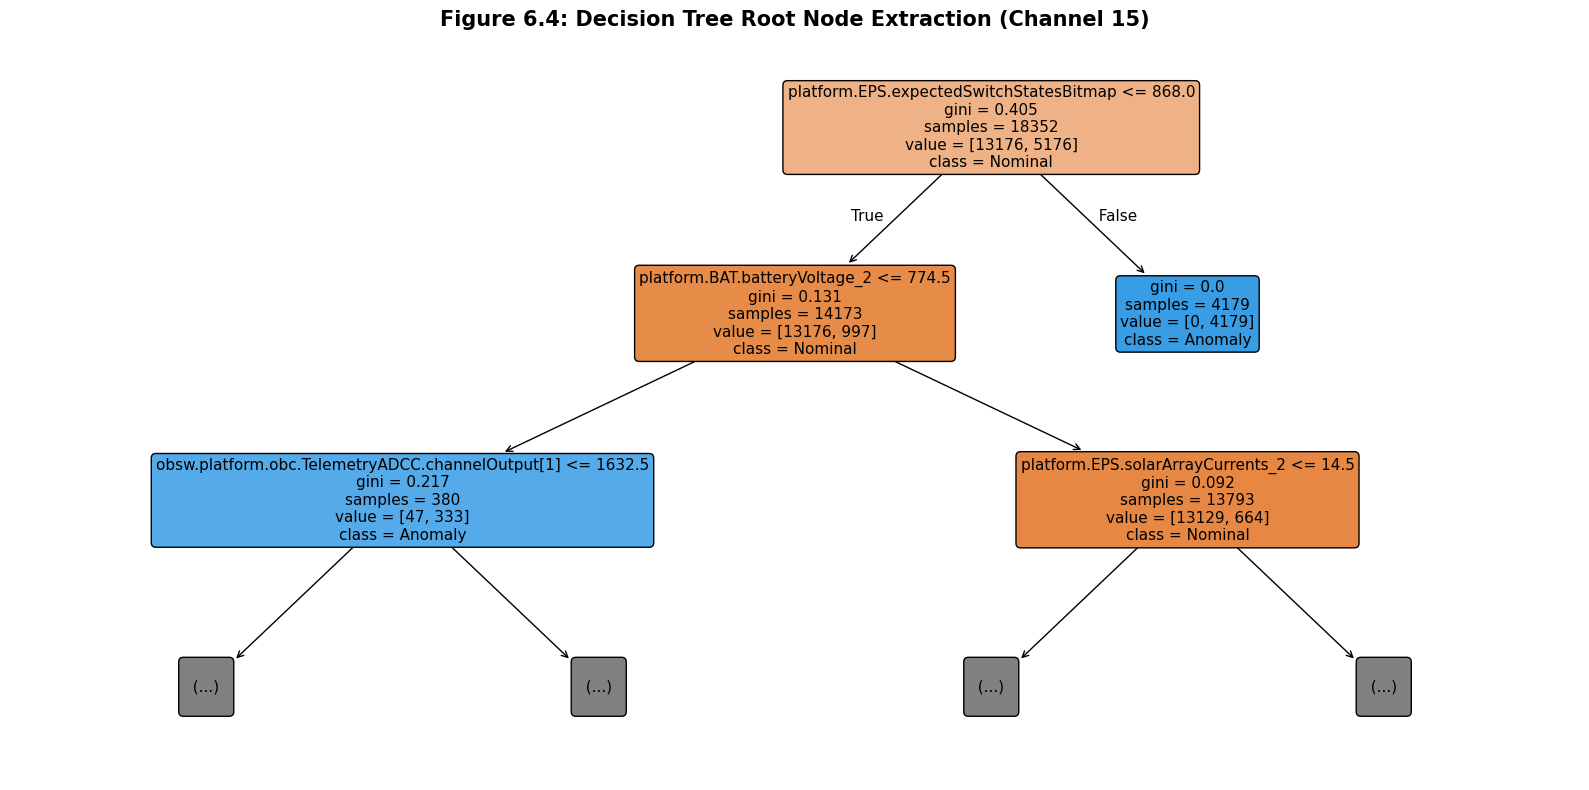

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, DecisionTreeClassifier

# 1. Re-initialize the exact Decision Tree model you evaluated in your notebook loop
# We set max_depth=3 so it doesn't overcomplicate the visualization
interpretable_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# Fit it to your current training data (Make sure this is your Channel 15 data!)
interpretable_tree.fit(X_train, y_train)

# 2. Set up a wide canvas so the boxes aren't squished together in your Word doc
plt.figure(figsize=(16, 8))

# 3. Plot the structure to extract the physical Root Node
plot_tree(interpretable_tree, 
          max_depth=2,            # CRITICAL: Only shows the top layers to keep it readable
          feature_names=X_train.columns, 
          class_names=['Nominal', 'Anomaly'], 
          filled=True,            # Colors the boxes based on the prediction
          rounded=True,           # Smooth edges for a polished look
          fontsize=11,
          proportion=False)       # Set to True if you want to see percentages instead of raw counts

# 4. Add the thesis-ready formatting
plt.title('Figure 6.4: Decision Tree Root Node Extraction (Channel 15)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

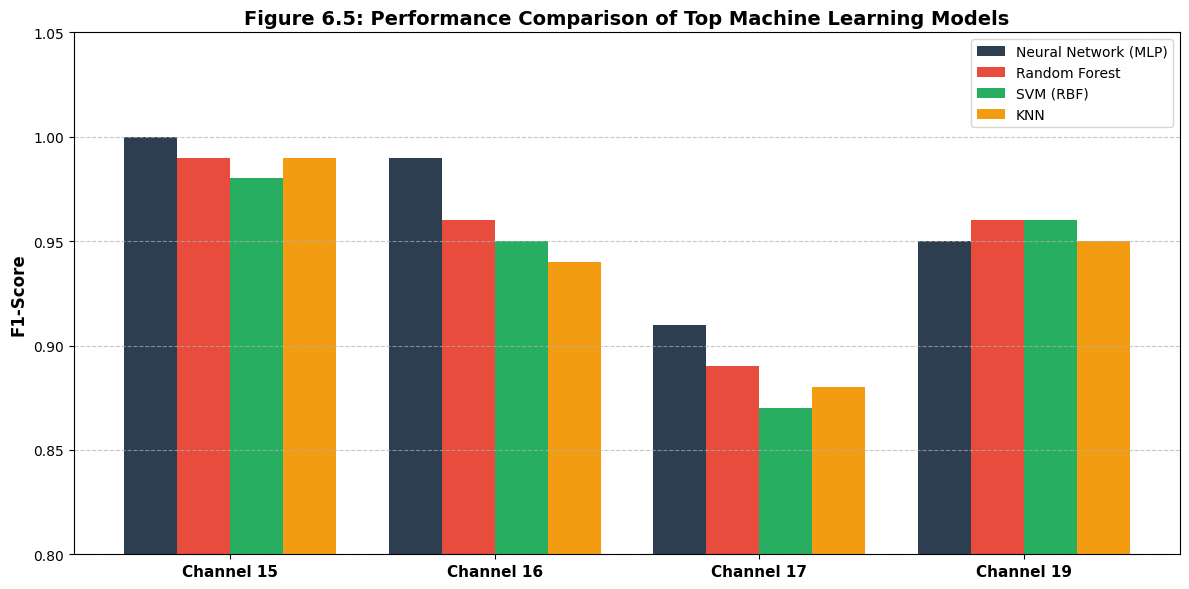

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Your exact F1-Scores based on the data you pasted earlier
channels = ['Channel 15', 'Channel 16', 'Channel 17', 'Channel 19']

# F1-Scores for the Top 4 Models
mlp_scores = [1.00, 0.99, 0.91, 0.95]
rf_scores  = [0.99, 0.96, 0.89, 0.96]
svm_scores = [0.98, 0.95, 0.87, 0.96]
knn_scores = [0.99, 0.94, 0.88, 0.95]

x = np.arange(len(channels))  # the label locations
width = 0.2  # the width of the bars

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting the bars
rects1 = ax.bar(x - 1.5*width, mlp_scores, width, label='Neural Network (MLP)', color='#2C3E50')
rects2 = ax.bar(x - 0.5*width, rf_scores, width, label='Random Forest', color='#E74C3C')
rects3 = ax.bar(x + 0.5*width, svm_scores, width, label='SVM (RBF)', color='#27AE60')
rects4 = ax.bar(x + 1.5*width, knn_scores, width, label='KNN', color='#F39C12')

# Formatting for your report
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Figure 6.5: Performance Comparison of Top Machine Learning Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(channels, fontsize=11, fontweight='bold')
ax.set_ylim(0.80, 1.05) # Zoomed in slightly so the differences are visible!
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for _, row in best_per_channel.iterrows():

    ch = int(row["Channel"])
    best_model_name = row["Model"]

    print("\n=================================")
    print(f"Channel {ch} | Best Model: {best_model_name}")
    print("=================================")

    df_c = tvac_df[tvac_df["Channel"] == ch].copy()

    # build paper-style features
    X, y = build_Xy_paper(df_c)

    # same split used in training
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        stratify=y,
        random_state=42
    )

    model = models[best_model_name]

    pipe = make_pipeline(model)

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal","Anomaly"],
        yticklabels=["Normal","Anomaly"]
    )

    plt.title(f"Confusion Matrix – Channel {ch}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


Flight-Test Channel 15 | Best Model: Neural Network (MLP)


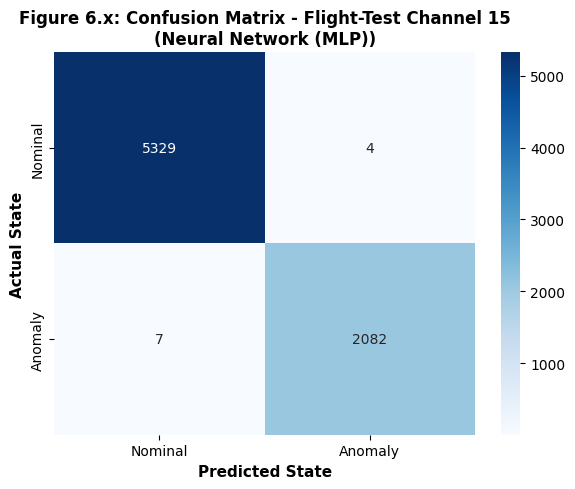


Flight-Test Channel 16 | Best Model: Neural Network (MLP)


C:\Users\jayan\AppData\Local\Temp\ipykernel_25396\932280574.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c.replace([np.inf, -np.inf], np.nan, inplace=True)


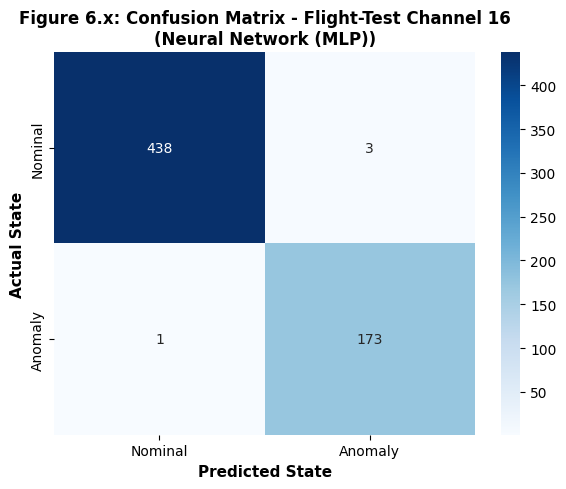


Flight-Test Channel 17 | Best Model: Neural Network (MLP)


C:\Users\jayan\AppData\Local\Temp\ipykernel_25396\932280574.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
c:\Users\jayan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


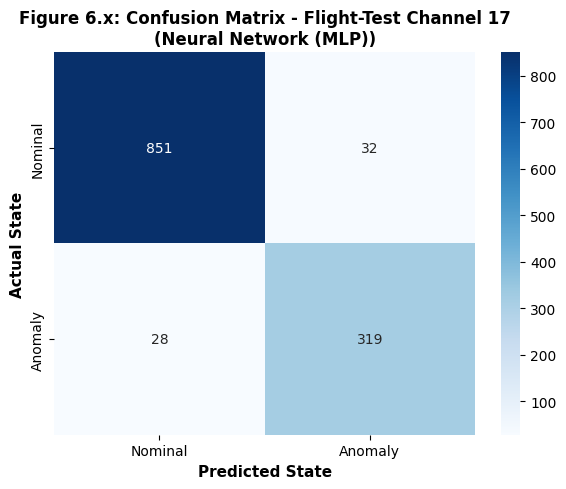


Flight-Test Channel 19 | Best Model: Random Forest


C:\Users\jayan\AppData\Local\Temp\ipykernel_25396\932280574.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c.replace([np.inf, -np.inf], np.nan, inplace=True)


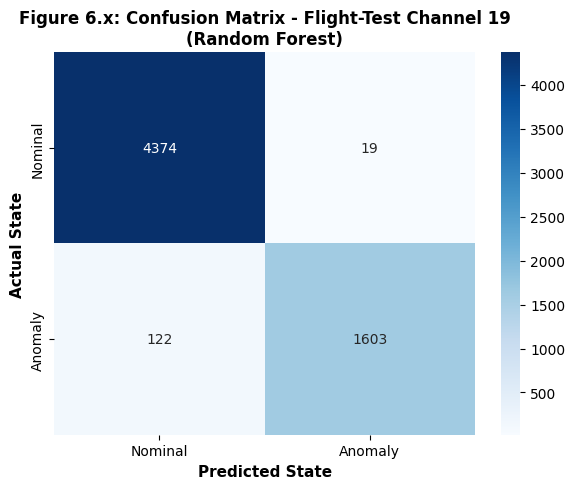

In [6]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the reigning champion algorithms for the Flight-Test channels (from Table 6.3)
best_flighttest_models = {
    15: ("Neural Network (MLP)", MLPClassifier(max_iter=500, random_state=42)),
    16: ("Neural Network (MLP)", MLPClassifier(max_iter=500, random_state=42)),
    17: ("Neural Network (MLP)", MLPClassifier(max_iter=500, random_state=42)),
    19: ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
}

# Ensure df is your flighttest_dataset.csv
# df = pd.read_csv('flighttest_dataset.csv', low_memory=False)

for ch, (model_name, model) in best_flighttest_models.items():
    print("\n=================================")
    print(f"Flight-Test Channel {ch} | Best Model: {model_name}")
    print("=================================")

    # 2. Isolate the channel data
    df_c = df[df['Channel'] == ch].copy()

    # 3. Combine all individual anomalies into a single target
    anomaly_columns = [col for col in df_c.columns if 'Anomaly' in col]
    if anomaly_columns:
        df_c['Anomaly_Bin'] = df_c[anomaly_columns].max(axis=1).fillna(0)
        df_c = df_c.drop(columns=anomaly_columns)

    # 4. Replace infinite values and drop columns containing missing values
    df_c.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_cleaned = df_c.dropna(axis=1)

    # 5. Separate Features and Target
    cols_to_drop = ['Anomaly_Bin', 'OBT', 'UTC_Timestamp', 'Row_ID', 'Channel']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df_cleaned.columns]

    X = df_cleaned.drop(columns=existing_cols_to_drop)
    X = X.select_dtypes(include=[np.number]) # Keep numeric only

    # Drop columns that exceed float32 max limits
    max_float32 = np.finfo(np.float32).max
    X_cols_to_drop = [col for col in X.columns if (X[col].abs() > max_float32).any()]
    X = X.drop(columns=X_cols_to_drop)

    y = df_c['Anomaly_Bin'].astype(int)

    # 6. 75/25 Stratified Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # 7. Build Pipeline: Scaler -> PCA (95% variance) -> Best Model
    pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', model)
    ])

    # 8. Fit Model and Predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # 9. Generate and Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Nominal", "Anomaly"], # Aerospace standard terminology
        yticklabels=["Nominal", "Anomaly"]
    )

    # Add thesis-ready formatting
    plt.title(f"Figure 6.x: Confusion Matrix - Flight-Test Channel {ch}\n({model_name})", fontsize=12, fontweight='bold')
    plt.xlabel("Predicted State", fontsize=11, fontweight='bold')
    plt.ylabel("Actual State", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()